# Module 5: Delivery Delay Prediction

## NovaMart AI Retail Intelligence Platform

### Overview

Timely delivery is a critical determinant of customer satisfaction and operational efficiency in e-commerce. Delayed deliveries can lead to poor customer reviews, increased customer support costs, and reduced customer retention.

This notebook develops a supervised machine learning model to predict whether an order is likely to be delivered late. The prediction enables proactive logistics management and supports operational decision-making.

The workflow includes data preparation, feature engineering, exploratory analysis, model training, evaluation, feature importance analysis, and model deployment.

## Objectives

- Build a delivery prediction dataset
- Engineer predictive logistics features
- Explore delivery patterns
- Train classification models
- Compare model performance
- Identify important delivery factors
- Save the best model for dashboard deployment

In [2]:
# ==========================================================
# Import Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [3]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    confusion_matrix,

    classification_report,

    roc_auc_score,

    roc_curve

)

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

## Load Dataset

In [4]:
retail = pd.read_csv("retail_master_dataset.csv")

## Dataset Overview

In [5]:
#Dataset Overview
retail.shape

(113049, 46)

In [6]:
retail.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments,payment_type,review_score,review_comment_title,review_comment_message,geolocation_zip_code_prefix,customer_lat,customer_lng,customer_geo_city,customer_geo_state,seller_lat,seller_lng,seller_geo_city,seller_geo_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.0,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,27277,volta redonda,SP,72.19,2.0,credit_card,5.0,NaN,"Perfeito, produto entregue antes do combinado.",28013.0,-21.763186,-41.310265,campos dos goytacazes,RJ,-22.497188,-44.127324,volta redonda,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.0,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,3471,sao paulo,SP,259.83,3.0,credit_card,4.0,NaN,NaN,15775.0,-20.222506,-50.898951,santa fe do sul,SP,-23.565754,-46.519097,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,7.0,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,37564,borda da mata,MG,216.87,5.0,credit_card,5.0,NaN,Chegou antes do prazo previsto e o produto sur...,35661.0,-19.869998,-44.593059,para de minas,MG,-22.262802,-46.170735,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.0,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery,14403,franca,SP,25.78,2.0,credit_card,4.0,NaN,NaN,12952.0,-23.105968,-46.590277,atibaia,SP,-20.553651,-47.387145,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.0,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools,87900,loanda,PR,218.04,3.0,credit_card,5.0,NaN,Gostei pois veio no prazo determinado .,13226.0,-23.243402,-46.827614,varzea paulista,SP,-22.929583,-53.135750,loanda,PR


In [7]:
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113049 entries, 0 to 113048
Data columns (total 46 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113049 non-null  object 
 1   order_item_id                  113049 non-null  int64  
 2   product_id                     113049 non-null  object 
 3   seller_id                      113049 non-null  object 
 4   shipping_limit_date            113049 non-null  object 
 5   price                          113049 non-null  float64
 6   freight_value                  113049 non-null  float64
 7   customer_id                    113049 non-null  object 
 8   order_status                   113049 non-null  object 
 9   order_purchase_timestamp       113049 non-null  object 
 10  order_approved_at              113034 non-null  object 
 11  order_delivered_carrier_date   111848 non-null  object 
 12  order_delivered_customer_date 

In [5]:
# ==========================================================
# Convert Date Columns
# ==========================================================

date_columns = [

    "order_purchase_timestamp",

    "order_approved_at",

    "order_delivered_carrier_date",

    "order_delivered_customer_date",

    "order_estimated_delivery_date"

]

for col in date_columns:

    retail[col] = pd.to_datetime(retail[col])

## Create Logistic Features

In [6]:
# ==========================================================
# Feature Engineering
# ==========================================================

# Processing Time
retail["processing_days"] = (

    retail["order_approved_at"]

    - retail["order_purchase_timestamp"]

).dt.days


# Shipping Time
retail["shipping_days"] = (

    retail["order_delivered_carrier_date"]

    - retail["order_approved_at"]

).dt.days


# Delivery Delay
retail["delivery_delay_days"] = (

    retail["order_delivered_customer_date"]

    - retail["order_estimated_delivery_date"]

).dt.days


# Product Volume
retail["product_volume_cm3"] = (

    retail["product_length_cm"]

    * retail["product_height_cm"]

    * retail["product_width_cm"]

)

## Target Variable
### Create Delivery Delay Target

In [7]:
# ==========================================================
# Target Variable
# ==========================================================

retail["Late_Delivery"] = np.where(

    retail["delivery_delay_days"] > 0,

    1,

    0

)

In [8]:
retail[

    [

        "processing_days",

        "shipping_days",

        "delivery_delay_days",

        "product_volume_cm3",

        "Late_Delivery"

    ]

].head()

,processing_days,shipping_days,delivery_delay_days,product_volume_cm3,Late_Delivery
0,0.0,6.0,-9.0,3528.0,0
1,0.0,8.0,-3.0,60000.0,0
2,0.0,1.0,-14.0,14157.0,0
3,0.0,2.0,-6.0,2400.0,0
4,0.0,11.0,-16.0,42000.0,0


In [9]:
# ==========================================================
# Select Features
# ==========================================================

features = [

    "price",
    "freight_value",
    "payment_value",
    "payment_installments",
    "processing_days",
    "shipping_days",
    "product_weight_g",
    "product_volume_cm3",
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "seller_state",
    "customer_state",
    "payment_type",
    "product_category_name"

]

delivery_df = retail[features + ["Late_Delivery"]].copy()

In [10]:
delivery_df.isnull().sum()

price                            0
freight_value                    0
payment_value                    3
payment_installments             3
processing_days                 15
shipping_days                 1216
product_weight_g                 0
product_volume_cm3               0
product_name_lenght              0
product_description_lenght       0
product_photos_qty               0
seller_state                     0
customer_state                   0
payment_type                     3
product_category_name            0
Late_Delivery                    0
dtype: int64

In [11]:
# Remove rows with missing values
delivery_df = delivery_df.dropna().reset_index(drop=True)

print(delivery_df.shape)

(111830, 16)


In [12]:
delivery_df.isnull().sum()

price                         0
freight_value                 0
payment_value                 0
payment_installments          0
processing_days               0
shipping_days                 0
product_weight_g              0
product_volume_cm3            0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
seller_state                  0
customer_state                0
payment_type                  0
product_category_name         0
Late_Delivery                 0
dtype: int64

### One-Hot Encode Categorical Variables

- Instead of LabelEncoder, This is preferable because:

- Random Forest and Decision Trees work well with one-hot encoded features.
- It avoids introducing an artificial order among categories.

In [13]:
categorical_columns = [

    "seller_state",

    "customer_state",

    "payment_type",

    "product_category_name"

]

delivery_df = pd.get_dummies(

    delivery_df,

    columns=categorical_columns,

    drop_first=True
)

## Create X and y

In [14]:
X = delivery_df.drop("Late_Delivery", axis=1)

y = delivery_df["Late_Delivery"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (111830, 134)
y Shape: (111830,)


## Prepare Machine Learning Dataset
### Feature Matrix and Target Variable

In [15]:
# ==========================================================
# Feature Matrix (X) and Target Variable (y)
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [16]:
# Save processed datasets for XAI

X_train.to_csv("delivery_X_train.csv", index=False)
X_test.to_csv("delivery_X_test.csv", index=False)

y_train.to_csv("delivery_y_train.csv", index=False)
y_test.to_csv("delivery_y_test.csv", index=False)

print("Processed delivery datasets saved successfully.")

Processed delivery datasets saved successfully.


## Train the Models

### 1. Logistic Regression

In [17]:
# ==========================================================
# Logistic Regression
# ==========================================================

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

### 2. Decision Tree

In [18]:
# ==========================================================
# Decision Tree
# ==========================================================

from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

### 3. Random Forest

In [19]:
# ==========================================================
# Random Forest
# ==========================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [20]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance.to_csv(
    "delivery_feature_importance.csv",
    index=False
)

## Evaluate the Models
Create an Evaluation Function

In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(model_name, y_true, y_pred):

    return pd.DataFrame({

        "Model":[model_name],

        "Accuracy":[accuracy_score(y_true, y_pred)],

        "Precision":[precision_score(y_true, y_pred)],

        "Recall":[recall_score(y_true, y_pred)],

        "F1-Score":[f1_score(y_true, y_pred)]

    })

In [36]:
results = pd.concat([

    evaluate_model(
        "Logistic Regression",
        y_test,
        log_pred
    ),

    evaluate_model(
        "Decision Tree",
        y_test,
        tree_pred
    ),

    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )

])

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.9436,0.8305,0.1682,0.2797
0,Decision Tree,0.9366,0.6067,0.0741,0.1321
0,Logistic Regression,0.9354,0.6250,0.0206,0.0399


## Business Insights
- The Random Forest model is the preferred choice for deployment because it provides the best overall predictive performance.
- Its high precision means that when the model flags an order as likely to be delayed, operations managers can be reasonably confident that intervention is warranted.
- The relatively low recall indicates that many delayed deliveries are not detected. As a result, the model should be viewed as a decision-support tool rather than a complete solution for identifying all late deliveries.
- Improving recall would allow NovaMart to proactively identify more at-risk orders, reducing customer complaints and improving service quality.

## Confusion Matrix

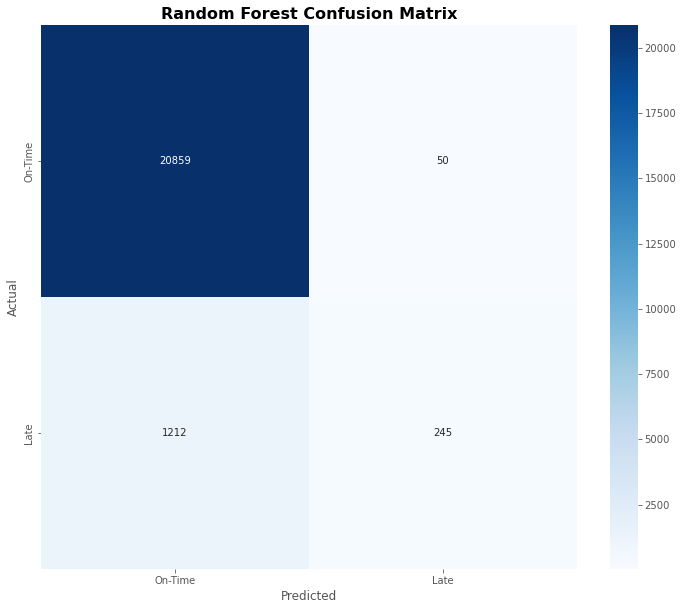

In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["On-Time", "Late"],
    yticklabels=["On-Time", "Late"]
)

plt.title(
    "Random Forest Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Classification Report

In [39]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97     20909
           1       0.83      0.17      0.28      1457

    accuracy                           0.94     22366
   macro avg       0.89      0.58      0.63     22366
weighted avg       0.94      0.94      0.93     22366



## ROC Curve

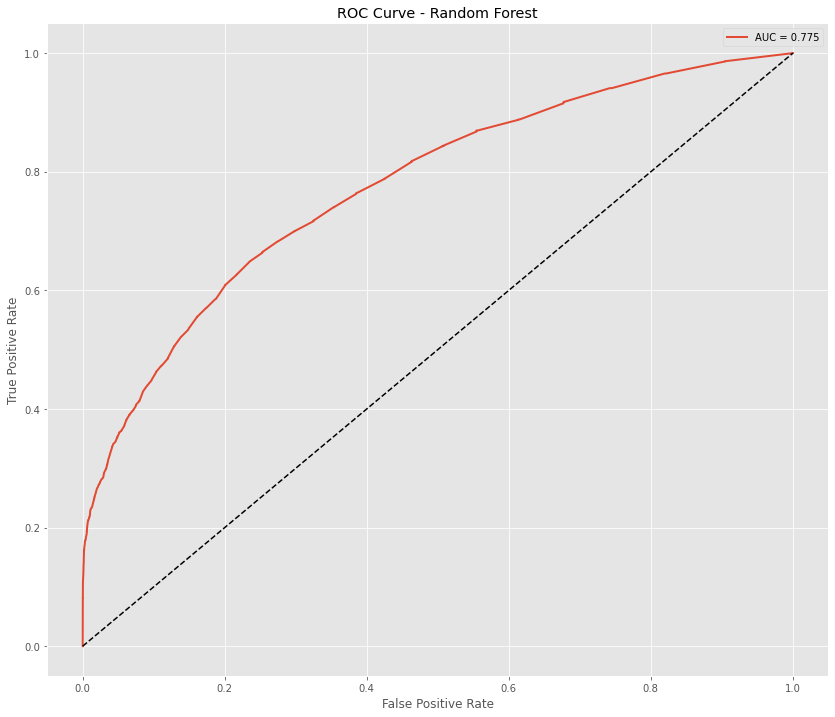

In [41]:
from sklearn.metrics import roc_curve, roc_auc_score

rf_prob = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, rf_prob)

auc = roc_auc_score(y_test, rf_prob)

plt.figure(figsize=(14,12))

plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.3f}")

plt.plot([0,1], [0,1], "k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Random Forest")

plt.legend()

plt.show()

## Apply SMOTE

In [42]:
# ==========================================================
# Balance the Training Data using SMOTE
# ==========================================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

## Check the Class Distribution

In [43]:
print("Before SMOTE")

print(y_train.value_counts())

print("\nAfter SMOTE")

print(y_train_smote.value_counts())

Before SMOTE
0    83637
1     5827
Name: Late_Delivery, dtype: int64

After SMOTE
0    83637
1    83637
Name: Late_Delivery, dtype: int64


In [44]:
#Retrain Logistic Regression
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(
    X_train_smote,
    y_train_smote
)

log_pred = log_model.predict(X_test)

In [45]:
#Retrain Decision Tree
tree_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

tree_model.fit(
    X_train_smote,
    y_train_smote
)

tree_pred = tree_model.predict(X_test)

In [46]:
rf_model = RandomForestClassifier(

    n_estimators=200,

    random_state=42,

    n_jobs=-1

)

rf_model.fit(

    X_train_smote,

    y_train_smote

)

rf_pred = rf_model.predict(X_test)

## Compare the Models 

In [47]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(name, y_true, y_pred):

    return pd.DataFrame({

        "Model":[name],

        "Accuracy":[accuracy_score(y_true, y_pred)],

        "Precision":[precision_score(y_true, y_pred)],

        "Recall":[recall_score(y_true, y_pred)],

        "F1-Score":[f1_score(y_true, y_pred)]

    })

results_smote = pd.concat([

    evaluate_model(
        "Logistic Regression",
        y_test,
        log_pred
    ),

    evaluate_model(
        "Decision Tree",
        y_test,
        tree_pred
    ),

    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )

])

results_smote = results_smote.sort_values(

    by="F1-Score",

    ascending=False

)

results_smote.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.9398,0.6418,0.1709,0.2699
0,Decision Tree,0.8410,0.1652,0.3555,0.2256
0,Logistic Regression,0.7287,0.1189,0.4935,0.1916


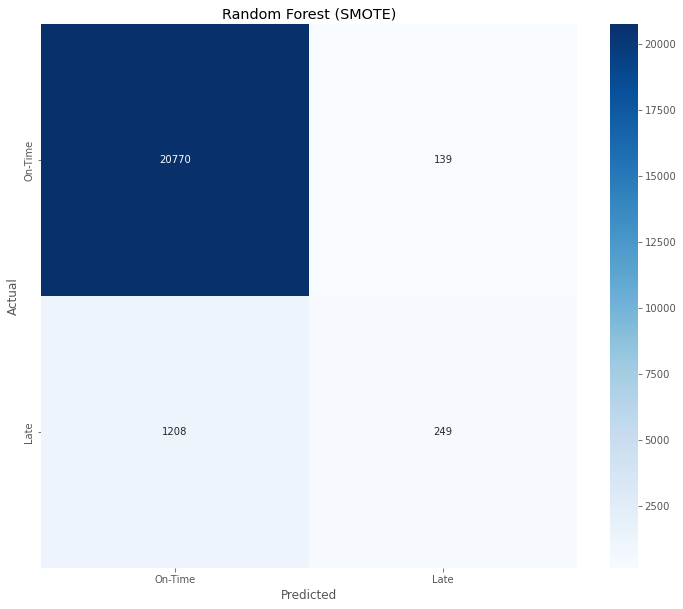

In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(12,10))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=["On-Time","Late"],

    yticklabels=["On-Time","Late"]

)

plt.title("Random Forest (SMOTE)")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [49]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     20909
           1       0.64      0.17      0.27      1457

    accuracy                           0.94     22366
   macro avg       0.79      0.58      0.62     22366
weighted avg       0.93      0.94      0.92     22366



## SMOTE did not improve the model; in fact, it slightly reduced its quality for the minority class.
| Metric (Late Delivery Class) | Before SMOTE | After SMOTE |         Change |
| ---------------------------- | -----------: | ----------: | -------------: |
| Precision                    |     **0.83** |    **0.64** |        ↓ Worse |
| Recall                       |     **0.17** |    **0.17** |      No change |
| F1-score                     |     **0.28** |    **0.27** | Slightly worse |
| Overall Accuracy             |     **0.94** |    **0.94** |      No change |


## Business Interpretation

The findings indicate that the available predictor variables do not provide sufficient information to clearly distinguish between on-time and late deliveries. Simply generating synthetic examples of delayed deliveries does not create additional discriminatory information, so the model's performance remains largely unchanged.

In [50]:
import joblib

joblib.dump(
    rf_model,
    "/models/random_forest_delivery_model.pkl"
)

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


In [54]:
feature_names = X_train.columns.tolist()

joblib.dump(
    feature_names,
    "/models/delivery_model_features.pkl"
)

print("Feature names saved successfully.")

Feature names saved successfully.


In [53]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": rf_model.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.to_csv(
    "delivery_feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


In [55]:
predictions = X_test.copy()

predictions["Actual"] = y_test.values
predictions["Predicted"] = rf_pred

predictions.to_csv(
    "delivery_predictions.csv",
    index=False
)

print("Predictions saved.")

Predictions saved.


In [57]:
import joblib
import os

os.makedirs("/models", exist_ok=True)

joblib.dump(
    rf_model,
    "random_forest_delivery_model.pkl"
)

joblib.dump(
    X_train.columns.tolist(),
    "delivery_model_features.pkl"
)

print("Delivery prediction model saved.")

Delivery prediction model saved.
